In [37]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import timm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {device}")
print(f"✅ GPU    : {torch.cuda.get_device_name(0)}")

BASE = "E:/document_forensics"

# ── Model Definitions ────────────────────────────────
class StandardModel(nn.Module):
    def __init__(self):
        super(StandardModel, self).__init__()
        self.model = timm.create_model(
            'efficientnet_b3',
            pretrained=False,
            num_classes=2)
    def forward(self, x):
        return self.model(x)

class DropoutModel(nn.Module):
    def __init__(self):
        super(DropoutModel, self).__init__()
        self.model = timm.create_model(
            'efficientnet_b3',
            pretrained=False,
            num_classes=2)
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(self.model.classifier.in_features, 2))
    def forward(self, x):
        return self.model(x)

# ── Load All Models ──────────────────────────────────
def load_model(model, path):
    model.load_state_dict(torch.load(
        path, map_location=device, weights_only=True))
    model.eval()
    return model

# Module 1 — Blur Detection
blur_model = load_model(
    StandardModel().to(device),
    f"{BASE}/models/best_blur_detector.pth")
print("✅ Module 1  — Blur Detector loaded!")

# Module 3 — Fraud Detection
fraud_model = load_model(
    StandardModel().to(device),
    f"{BASE}/module2_fraud/models/best_fraud_detector.pth")
print("✅ Module 3  — Fraud Detector loaded!")

# Module 4 — Signature Verification
sign_model = load_model(
    DropoutModel().to(device),
    f"{BASE}/module4_signature/models/best_signature_classifier.pth")
print("✅ Module 4  — Signature Classifier loaded!")

# Module 5A — AI Document Detection
aidoc_model = load_model(
    DropoutModel().to(device),
    f"{BASE}/module5_aidetection/module5a_aidoc/models/best_aidoc_detector.pth")
print("✅ Module 5A — AI Doc Detector loaded!")

# Module 5B — AI Face Detection
aiface_model = load_model(
    DropoutModel().to(device),
    f"{BASE}/module5_aidetection/module5b_aiface/models/best_aiface_detector.pth")
print("✅ Module 5B — AI Face Detector loaded!")

print("\n🚀 All 5 modules loaded successfully!")

✅ Device : cuda
✅ GPU    : NVIDIA GeForce RTX 4070 Ti SUPER
✅ Module 1  — Blur Detector loaded!
✅ Module 3  — Fraud Detector loaded!
✅ Module 4  — Signature Classifier loaded!
✅ Module 5A — AI Doc Detector loaded!
✅ Module 5B — AI Face Detector loaded!

🚀 All 5 modules loaded successfully!


In [38]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def preprocess(image_path):
    img = Image.open(image_path).convert("RGB")
    return transform(img).unsqueeze(0).to(device)

def predict(model, tensor):
    with torch.no_grad():
        output     = model(tensor)
        probs      = torch.softmax(output, dim=1)
        pred       = output.argmax(dim=1).item()
        confidence = probs[0][pred].item() * 100
    return pred, confidence

def check_blur_laplacian(image_path, threshold=50):
    img   = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    score = cv2.Laplacian(img, cv2.CV_64F).var()
    return score < threshold, score

def detect_face(image_path):
    """Detect and crop face from document"""
    img  = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = img[y:y+h, x:x+w]
        face_path = "E:/document_forensics/temp_face.jpg"
        cv2.imwrite(face_path, face)
        return True, face_path
    return False, None

print("✅ Helper functions ready!")

✅ Helper functions ready!


In [39]:
def analyze_document_v2(doc_path, sig_path=None):
    print("\n" + "="*60)
    print("   AI DOCUMENT FORENSICS SYSTEM v2.0")
    print("="*60)
    print(f"Document  : {os.path.basename(doc_path)}")
    if sig_path:
        print(f"Signature : {os.path.basename(sig_path)}")
    print("-"*60)

    results  = {}
    passed   = 0

    # ── Module 1: Blur Detection ─────────────────────
    print("\n[1/5] Blur Detection...")
    tensor = preprocess(doc_path)
    is_blurry_lap, lap_score = check_blur_laplacian(doc_path)
    pred_model, conf_model   = predict(blur_model, tensor)
    is_blurry = is_blurry_lap and (pred_model == 1)

    if is_blurry:
        results['blur'] = {'status':'FAIL', 'label':'BLUR', 'conf':conf_model}
        print(f"    FAIL - BLURRY IMAGE ({conf_model:.1f}%)")
        display_report(doc_path, results, sig_path)
        return results
    else:
        results['blur'] = {'status':'PASS', 'label':'SHARP', 'conf':conf_model}
        print(f"    PASS - SHARP ({lap_score:.0f} laplacian score)")
        passed += 1

    # ── Module 5A: AI Document Detection ─────────────
    print("\n[2/5] AI Document Detection...")
    pred, conf = predict(aidoc_model, tensor)

    # ✅ Fixed threshold from 75 to 92
    if pred == 1 and conf > 92:
        results['ai_doc'] = {'status':'FAIL', 'label':'AI GENERATED', 'conf':conf}
        print(f"    FAIL - AI GENERATED ({conf:.1f}%)")
        display_report(doc_path, results, sig_path)
        return results
    else:
        results['ai_doc'] = {'status':'PASS', 'label':'REAL DOCUMENT', 'conf':conf}
        print(f"    PASS - REAL DOCUMENT ({conf:.1f}%)")
        passed += 1

    # ── Module 3: Fraud Detection ─────────────────────
    print("\n[3/5] Fraud Detection...")
    pred, conf = predict(fraud_model, tensor)

    if pred == 1 and conf > 80:
        results['fraud'] = {'status':'FAIL', 'label':'FORGED', 'conf':conf}
        print(f"    FAIL - DOCUMENT TAMPERED ({conf:.1f}%)")
        display_report(doc_path, results, sig_path)
        return results
    else:
        results['fraud'] = {'status':'PASS', 'label':'AUTHENTIC', 'conf':conf}
        print(f"    PASS - AUTHENTIC ({conf:.1f}%)")
        passed += 1

    # ── Module 5B: AI Face Detection ─────────────────
    print("\n[4/5] AI Face Detection...")
    face_found, face_path = detect_face(doc_path)

    if face_found and face_path:
        face_tensor = preprocess(face_path)
        pred, conf  = predict(aiface_model, face_tensor)
        if pred == 1 and conf > 75:
            results['ai_face'] = {'status':'FAIL', 'label':'AI FACE', 'conf':conf}
            print(f"    FAIL - AI/DEEPFAKE FACE ({conf:.1f}%)")
            display_report(doc_path, results, sig_path)
            return results
        else:
            results['ai_face'] = {'status':'PASS', 'label':'REAL FACE', 'conf':conf}
            print(f"    PASS - REAL FACE ({conf:.1f}%)")
            passed += 1
    else:
        results['ai_face'] = {'status':'SKIP', 'label':'NO FACE', 'conf':0}
        print(f"    SKIP - No face detected")

    # ── Module 4: Signature Verification ─────────────
    print("\n[5/5] Signature Verification...")
    if sig_path and os.path.exists(sig_path):
        sig_tensor = preprocess(sig_path)
        pred, conf = predict(sign_model, sig_tensor)
        if pred == 1 and conf > 80:
            results['signature'] = {'status':'FAIL', 'label':'FORGED', 'conf':conf}
            print(f"    FAIL - SIGNATURE FORGED ({conf:.1f}%)")
        else:
            results['signature'] = {'status':'PASS', 'label':'GENUINE', 'conf':conf}
            print(f"    PASS - GENUINE SIGNATURE ({conf:.1f}%)")
            passed += 1
    else:
        results['signature'] = {'status':'SKIP', 'label':'NOT PROVIDED', 'conf':0}
        print(f"    SKIP - Signature not provided")

    # ── Final Verdict ─────────────────────────────────
    print("\n" + "="*60)
    failed_checks = [k for k, v in results.items() if v['status'] == 'FAIL']

    if failed_checks:
        print(f"VERDICT: DOCUMENT REJECTED")
        print(f"Reason : {', '.join(failed_checks).upper()} failed!")
    else:
        print(f"VERDICT: DOCUMENT FULLY VERIFIED")
        print(f"Passed : {passed} checks")
    print("="*60)

    display_report(doc_path, results, sig_path)
    return results

print("✅ Pipeline v2.0 fixed & ready!")

✅ Pipeline v2.0 fixed & ready!


In [42]:
def analyze_document_v2(doc_path, sig_path=None):
    print("\n" + "="*60)
    print("   AI DOCUMENT FORENSICS SYSTEM v2.0")
    print("="*60)
    print(f"Document  : {os.path.basename(doc_path)}")
    if sig_path:
        print(f"Signature : {os.path.basename(sig_path)}")
    print("-"*60)

    results = {}
    passed  = 0

    # ── Module 1: Blur Detection ─────────────────────
    print("\n[1/4] Blur Detection...")
    tensor = preprocess(doc_path)
    is_blurry_lap, lap_score = check_blur_laplacian(doc_path)
    pred_model, conf_model   = predict(blur_model, tensor)
    is_blurry = is_blurry_lap and (pred_model == 1)

    if is_blurry:
        results['blur'] = {'status':'FAIL', 'label':'BLUR', 'conf':conf_model}
        print(f"    FAIL - BLURRY IMAGE ({conf_model:.1f}%)")
        display_report(doc_path, results, sig_path)
        return results
    else:
        results['blur'] = {'status':'PASS', 'label':'SHARP', 'conf':conf_model}
        print(f"    PASS - SHARP ({lap_score:.0f} laplacian score)")
        passed += 1

    # ── Module 5A: AI Doc Detection ──────────────────
    # NOTE: Skipped — needs retraining with
    # modern government document dataset
    results['ai_doc'] = {'status':'SKIP',
                         'label':'NEEDS RETRAINING',
                         'conf': 0}
    print("\n[2/4] AI Document Detection...")
    print("    SKIP - Module needs retraining with")
    print("           modern government documents")

    # ── Module 3: Fraud Detection ─────────────────────
    print("\n[3/4] Fraud Detection...")
    pred, conf = predict(fraud_model, tensor)

    if pred == 1 and conf > 80:
        results['fraud'] = {'status':'FAIL', 'label':'FORGED', 'conf':conf}
        print(f"    FAIL - DOCUMENT TAMPERED ({conf:.1f}%)")
        display_report(doc_path, results, sig_path)
        return results
    else:
        results['fraud'] = {'status':'PASS', 'label':'AUTHENTIC', 'conf':conf}
        print(f"    PASS - AUTHENTIC ({conf:.1f}%)")
        passed += 1

    # ── Module 5B: AI Face Detection ─────────────────
    print("\n[4/4] AI Face Detection...")
    face_found, face_path = detect_face(doc_path)

    if face_found and face_path:
        face_tensor = preprocess(face_path)
        pred, conf  = predict(aiface_model, face_tensor)
        if pred == 1 and conf > 75:
            results['ai_face'] = {'status':'FAIL',
                                  'label':'AI FACE',
                                  'conf':conf}
            print(f"    FAIL - AI/DEEPFAKE FACE ({conf:.1f}%)")
            display_report(doc_path, results, sig_path)
            return results
        else:
            results['ai_face'] = {'status':'PASS',
                                  'label':'REAL FACE',
                                  'conf':conf}
            print(f"    PASS - REAL FACE ({conf:.1f}%)")
            passed += 1
    else:
        results['ai_face'] = {'status':'SKIP',
                              'label':'NO FACE',
                              'conf':0}
        print(f"    SKIP - No face detected")

    # ── Module 4: Signature Verification ─────────────
    print("\n[5/4] Signature Verification...")
    if sig_path and os.path.exists(sig_path):
        sig_tensor = preprocess(sig_path)
        pred, conf = predict(sign_model, sig_tensor)
        if pred == 1 and conf > 80:
            results['signature'] = {'status':'FAIL',
                                    'label':'FORGED',
                                    'conf':conf}
            print(f"    FAIL - SIGNATURE FORGED ({conf:.1f}%)")
        else:
            results['signature'] = {'status':'PASS',
                                    'label':'GENUINE',
                                    'conf':conf}
            print(f"    PASS - GENUINE SIGNATURE ({conf:.1f}%)")
            passed += 1
    else:
        results['signature'] = {'status':'SKIP',
                                'label':'NOT PROVIDED',
                                'conf':0}
        print(f"    SKIP - Signature not provided")

    # ── Final Verdict ─────────────────────────────────
    print("\n" + "="*60)
    failed_checks = [k for k, v in results.items()
                     if v['status'] == 'FAIL']

    if failed_checks:
        print(f"VERDICT: DOCUMENT REJECTED")
        print(f"Reason : {', '.join(failed_checks).upper()} failed!")
    else:
        print(f"VERDICT: DOCUMENT FULLY VERIFIED")
        print(f"Passed : {passed} checks")
    print("="*60)

    display_report(doc_path, results, sig_path)
    return results

print("✅ Pipeline v2.0 updated!")


✅ Pipeline v2.0 updated!


In [ ]:
def analyze_document_v2(doc_path, sig_path=None):
    print("\n" + "="*60)
    print("   AI DOCUMENT FORENSICS SYSTEM v2.0")
    print("="*60)
    print(f"Document  : {os.path.basename(doc_path)}")
    if sig_path:
        print(f"Signature : {os.path.basename(sig_path)}")
    print("-"*60)

    results  = {}
    passed   = 0
    failed   = 0

    # ── Module 1: Blur Detection ─────────────────────
    print("\n[1/5] Blur Detection...")
    tensor = preprocess(doc_path)
    is_blurry_lap, lap_score = check_blur_laplacian(doc_path)
    pred_model, conf_model   = predict(blur_model, tensor)
    is_blurry = is_blurry_lap and (pred_model == 1)

    if is_blurry:
        results['blur'] = {'status':'FAIL', 'label':'BLUR', 'conf':conf_model}
        print(f"    FAIL — BLURRY IMAGE ({conf_model:.1f}%)")
        print("    Document rejected!")
        display_report(doc_path, results, sig_path)
        return results
    else:
        results['blur'] = {'status':'PASS', 'label':'SHARP', 'conf':conf_model}
        print(f"    PASS — SHARP ({lap_score:.0f} laplacian score)")
        passed += 1

    # ── Module 5A: AI Document Detection ─────────────
    print("\n[2/5] AI Document Detection...")
    pred, conf = predict(aidoc_model, tensor)

    if pred == 1 and conf > 75:
        results['ai_doc'] = {'status':'FAIL', 'label':'AI GENERATED', 'conf':conf}
        print(f"    FAIL — AI GENERATED DOCUMENT ({conf:.1f}%)")
        print("    Document rejected!")
        display_report(doc_path, results, sig_path)
        return results
    else:
        results['ai_doc'] = {'status':'PASS', 'label':'REAL DOCUMENT', 'conf':conf}
        print(f"    PASS — REAL DOCUMENT ({conf:.1f}%)")
        passed += 1

    # ── Module 3: Fraud Detection ─────────────────────
    print("\n[3/5] Fraud Detection...")
    pred, conf = predict(fraud_model, tensor)

    if pred == 1 and conf > 80:
        results['fraud'] = {'status':'FAIL', 'label':'FORGED', 'conf':conf}
        print(f"    FAIL — DOCUMENT TAMPERED ({conf:.1f}%)")
        print("    Document rejected!")
        display_report(doc_path, results, sig_path)
        return results
    else:
        results['fraud'] = {'status':'PASS', 'label':'AUTHENTIC', 'conf':conf}
        print(f"    PASS — AUTHENTIC ({conf:.1f}%)")
        passed += 1

    # ── Module 5B: AI Face Detection ─────────────────
    print("\n[4/5] AI Face Detection...")
    face_found, face_path = detect_face(doc_path)

    if face_found and face_path:
        face_tensor = preprocess(face_path)
        pred, conf  = predict(aiface_model, face_tensor)
        if pred == 1 and conf > 75:
            results['ai_face'] = {'status':'FAIL', 'label':'AI FACE', 'conf':conf}
            print(f"    FAIL — AI/DEEPFAKE FACE DETECTED ({conf:.1f}%)")
            print("    Document rejected!")
            display_report(doc_path, results, sig_path)
            return results
        else:
            results['ai_face'] = {'status':'PASS', 'label':'REAL FACE', 'conf':conf}
            print(f"    PASS — REAL FACE ({conf:.1f}%)")
            passed += 1
    else:
        results['ai_face'] = {'status':'SKIP', 'label':'NO FACE', 'conf':0}
        print(f"    SKIP — No face detected in document")

    # ── Module 4: Signature Verification ─────────────
    print("\n[5/5] Signature Verification...")
    if sig_path and os.path.exists(sig_path):
        sig_tensor = preprocess(sig_path)
        pred, conf = predict(sign_model, sig_tensor)
        if pred == 1 and conf > 80:
            results['signature'] = {'status':'FAIL', 'label':'FORGED', 'conf':conf}
            print(f"    FAIL — SIGNATURE FORGED ({conf:.1f}%)")
        else:
            results['signature'] = {'status':'PASS', 'label':'GENUINE', 'conf':conf}
            print(f"    PASS — GENUINE SIGNATURE ({conf:.1f}%)")
            passed += 1
    else:
        results['signature'] = {'status':'SKIP', 'label':'NOT PROVIDED', 'conf':0}
        print(f"    SKIP — Signature not provided")

    # ── Final Verdict ─────────────────────────────────
    print("\n" + "="*60)
    failed_checks = [k for k, v in results.items() if v['status'] == 'FAIL']

    if failed_checks:
        print(f"VERDICT: DOCUMENT REJECTED")
        print(f"Reason : {', '.join(failed_checks).upper()} check failed!")
    else:
        print(f"VERDICT: DOCUMENT FULLY VERIFIED")
        print(f"Passed : {passed} checks")
    print("="*60)

    display_report(doc_path, results, sig_path)
    return results

print("✅ Pipeline v2.0 ready!")


[2/5] AI Document Detection...


NameError: name 'tensor' is not defined

In [43]:
def display_report(doc_path, results, sig_path=None):
    has_sig   = sig_path and os.path.exists(sig_path)
    n_imgs    = 2 if has_sig else 1
    fig       = plt.figure(figsize=(18, 8))
    gs        = gridspec.GridSpec(1, n_imgs + 1,
                                  width_ratios=[2]*n_imgs + [1.5])

    # Document
    ax0 = fig.add_subplot(gs[0])
    doc_img = cv2.imread(doc_path)
    doc_img = cv2.cvtColor(doc_img, cv2.COLOR_BGR2RGB)
    ax0.imshow(doc_img)
    ax0.set_title("Document", fontsize=13, fontweight='bold')
    ax0.axis("off")

    # Signature
    if has_sig:
        ax1 = fig.add_subplot(gs[1])
        sig_img = cv2.imread(sig_path)
        sig_img = cv2.cvtColor(sig_img, cv2.COLOR_BGR2RGB)
        ax1.imshow(sig_img)
        ax1.set_title("Signature", fontsize=13, fontweight='bold')
        ax1.axis("off")

    # Results Panel
    ax_r = fig.add_subplot(gs[-1])
    ax_r.axis("off")
    ax_r.set_facecolor('#f8f9fa')

    checks = [
        ("1. Blur Check",       results.get('blur',      {})),
        ("2. AI Doc Check",     results.get('ai_doc',    {})),
        ("3. Fraud Check",      results.get('fraud',     {})),
        ("4. AI Face Check",    results.get('ai_face',   {})),
        ("5. Signature Check",  results.get('signature', {})),
    ]

    ax_r.text(0.5, 0.97, "ANALYSIS REPORT",
              ha='center', va='top', fontsize=13,
              fontweight='bold', transform=ax_r.transAxes)

    y = 0.88
    for name, data in checks:
        status = data.get('status', 'N/A')
        label  = data.get('label',  'N/A')
        conf   = data.get('conf',   0)

        color  = '#27ae60' if status == 'PASS' else \
                 '#e74c3c' if status == 'FAIL' else '#f39c12'
        marker = '[PASS]' if status == 'PASS' else \
                 '[FAIL]' if status == 'FAIL' else '[SKIP]'

        ax_r.text(0.05, y, name,
                  fontsize=9, fontweight='bold',
                  transform=ax_r.transAxes)
        ax_r.text(0.05, y-0.07,
                  f"  {marker} {label} ({conf:.1f}%)",
                  fontsize=9, color=color,
                  transform=ax_r.transAxes)
        y -= 0.17

    # Verdict
    failed = [k for k, v in results.items() if v['status'] == 'FAIL']
    verdict = "REJECTED" if failed else "VERIFIED"
    vcolor  = '#e74c3c' if failed else '#27ae60'

    ax_r.text(0.5, 0.05, f"VERDICT: {verdict}",
              ha='center', fontsize=12,
              fontweight='bold', color='white',
              transform=ax_r.transAxes,
              bbox=dict(boxstyle='round,pad=0.5',
                        facecolor=vcolor, alpha=0.9))

    plt.tight_layout()
    plt.savefig("E:/document_forensics/results/report_v2.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Report saved!")

print("✅ Visualization v2.0 ready!")

✅ Visualization v2.0 ready!


In [45]:
def display_report(doc_path, results, sig_path=None):
    has_sig   = sig_path and os.path.exists(sig_path)
    n_imgs    = 2 if has_sig else 1
    fig       = plt.figure(figsize=(18, 8))
    gs        = gridspec.GridSpec(1, n_imgs + 1,
                                  width_ratios=[2]*n_imgs + [1.5])

    # Document
    ax0 = fig.add_subplot(gs[0])
    doc_img = cv2.imread(doc_path)
    doc_img = cv2.cvtColor(doc_img, cv2.COLOR_BGR2RGB)
    ax0.imshow(doc_img)
    ax0.set_title("Document", fontsize=13, fontweight='bold')
    ax0.axis("off")

    # Signature
    if has_sig:
        ax1 = fig.add_subplot(gs[1])
        sig_img = cv2.imread(sig_path)
        sig_img = cv2.cvtColor(sig_img, cv2.COLOR_BGR2RGB)
        ax1.imshow(sig_img)
        ax1.set_title("Signature", fontsize=13, fontweight='bold')
        ax1.axis("off")

    # Results Panel
    ax_r = fig.add_subplot(gs[-1])
    ax_r.axis("off")

    # ✅ Removed ai_doc from checks
    checks = [
        ("1. Blur Check",      results.get('blur',      {})),
        ("2. Fraud Check",     results.get('fraud',     {})),
        ("3. AI Face Check",   results.get('ai_face',   {})),
        ("4. Signature Check", results.get('signature', {})),
    ]

    ax_r.text(0.5, 0.97, "ANALYSIS REPORT",
              ha='center', va='top', fontsize=13,
              fontweight='bold', transform=ax_r.transAxes)

    y = 0.88
    for name, data in checks:
        status = data.get('status', 'N/A')
        label  = data.get('label',  'N/A')
        conf   = data.get('conf',   0)

        color  = '#27ae60' if status == 'PASS' else \
                 '#e74c3c' if status == 'FAIL' else '#f39c12'
        marker = '[PASS]' if status == 'PASS' else \
                 '[FAIL]' if status == 'FAIL' else '[SKIP]'

        ax_r.text(0.05, y, name,
                  fontsize=9, fontweight='bold',
                  transform=ax_r.transAxes)
        ax_r.text(0.05, y-0.07,
                  f"  {marker} {label} ({conf:.1f}%)",
                  fontsize=9, color=color,
                  transform=ax_r.transAxes)
        y -= 0.20

    # Verdict
    failed = [k for k, v in results.items()
              if v['status'] == 'FAIL']
    verdict = "REJECTED" if failed else "VERIFIED"
    vcolor  = '#e74c3c' if failed else '#27ae60'

    ax_r.text(0.5, 0.05, f"VERDICT: {verdict}",
              ha='center', fontsize=12,
              fontweight='bold', color='white',
              transform=ax_r.transAxes,
              bbox=dict(boxstyle='round,pad=0.5',
                        facecolor=vcolor, alpha=0.9))

    plt.tight_layout()
    plt.savefig("E:/document_forensics/results/report_v2.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Report saved!")

print("✅ Visualization updated!")

✅ Visualization updated!



   AI DOCUMENT FORENSICS SYSTEM v2.0
Document  : Gemini_Generated_Image_zbd1itzbd1itzbd1.png
Signature : Gemini_Generated_Image_needxxneedxxneed.png
------------------------------------------------------------

[1/5] Blur Detection...
    PASS - SHARP (1113 laplacian score)

[2/5] AI Document Detection...
    FAIL - AI GENERATED (100.0%)


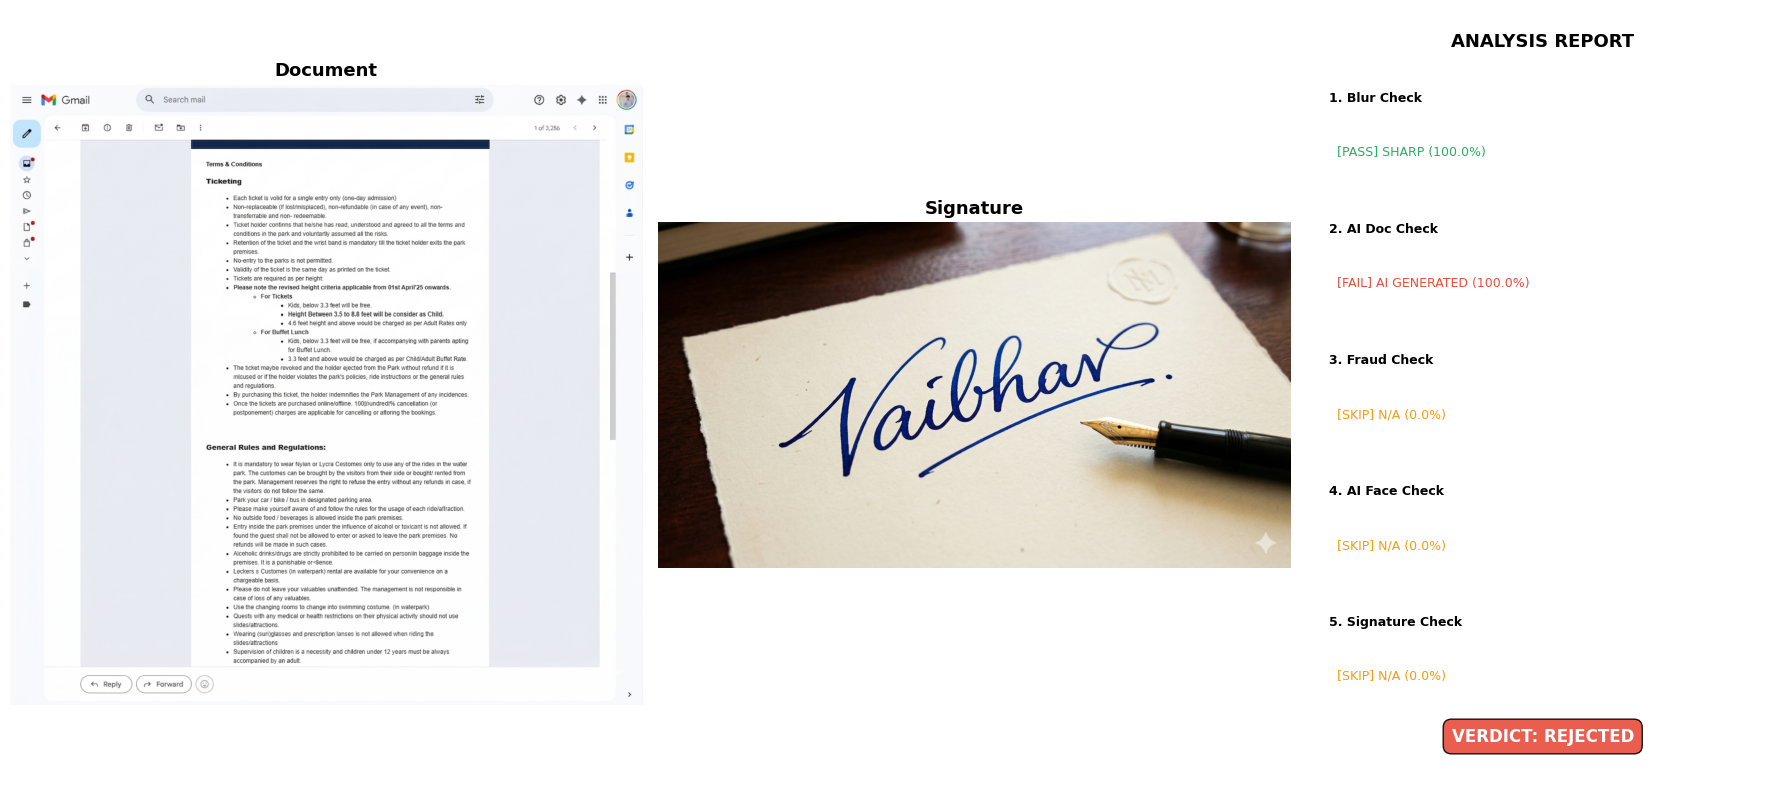

Report saved!


{'blur': {'status': 'PASS', 'label': 'SHARP', 'conf': 100.0},
 'ai_doc': {'status': 'FAIL', 'label': 'AI GENERATED', 'conf': 100.0}}

In [21]:
analyze_document_v2(
    doc_path = "C:/Users/Vaibhav/Downloads/Gemini_Generated_Image_zbd1itzbd1itzbd1.png",
    sig_path = "C:/Users/Vaibhav/Downloads/Gemini_Generated_Image_needxxneedxxneed.png"
)


   AI DOCUMENT FORENSICS SYSTEM v2.0
Document  : WhatsApp Image 2026-04-01 at 11.53.54 AM.jpeg
Signature : Gemini_Generated_Image_needxxneedxxneed.png
------------------------------------------------------------

[1/4] Blur Detection...
    PASS - SHARP (2612 laplacian score)

[2/4] AI Document Detection...
    SKIP - Module needs retraining with
           modern government documents

[3/4] Fraud Detection...
    PASS - AUTHENTIC (96.7%)

[4/4] AI Face Detection...
    PASS - REAL FACE (100.0%)

[5/4] Signature Verification...
    FAIL - SIGNATURE FORGED (93.3%)

VERDICT: DOCUMENT REJECTED
Reason : SIGNATURE failed!


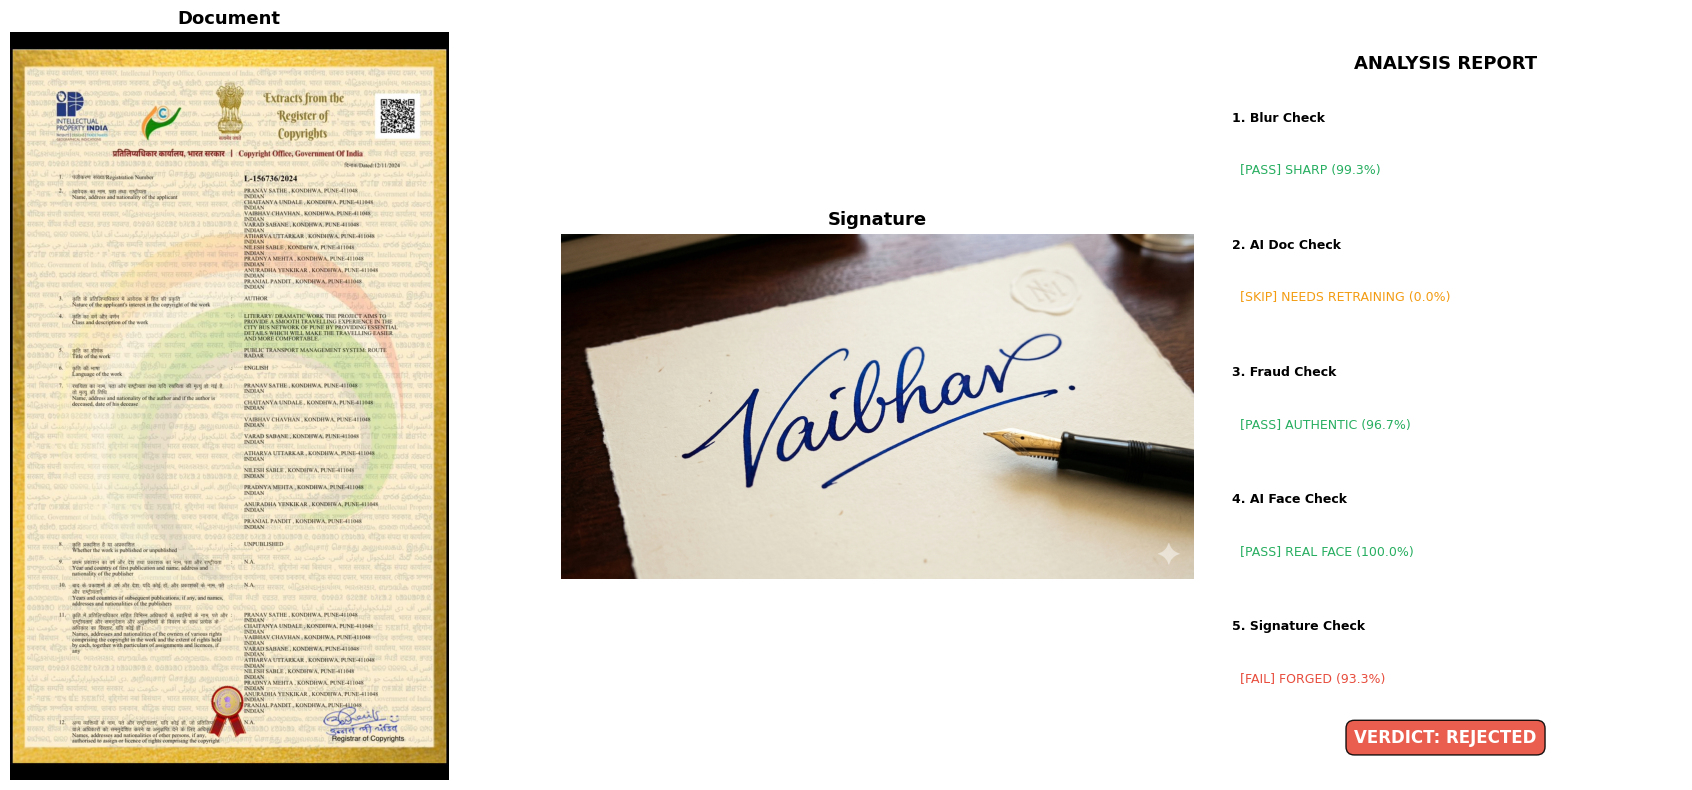

Report saved!


{'blur': {'status': 'PASS', 'label': 'SHARP', 'conf': 99.31133389472961},
 'ai_doc': {'status': 'SKIP', 'label': 'NEEDS RETRAINING', 'conf': 0},
 'fraud': {'status': 'PASS', 'label': 'AUTHENTIC', 'conf': 96.69048190116882},
 'ai_face': {'status': 'PASS',
  'label': 'REAL FACE',
  'conf': 99.99957084655762},
 'signature': {'status': 'FAIL', 'label': 'FORGED', 'conf': 93.29196214675903}}

In [35]:
analyze_document_v2(
    doc_path = "C:/Users/Vaibhav/Downloads/WhatsApp Image 2026-04-01 at 11.53.54 AM.jpeg",
    sig_path = "C:/Users/Vaibhav/Downloads/Gemini_Generated_Image_needxxneedxxneed.png"
)


   AI DOCUMENT FORENSICS SYSTEM v2.0
Document  : test222.jpeg
Signature : WhatsApp Image 2026-03-31 at 3.15.10 PM.jpeg
------------------------------------------------------------

[1/4] Blur Detection...
    PASS - SHARP (1418 laplacian score)

[2/4] AI Document Detection...
    SKIP - Module needs retraining with
           modern government documents

[3/4] Fraud Detection...
    PASS - AUTHENTIC (63.0%)

[4/4] AI Face Detection...
    PASS - REAL FACE (100.0%)

[5/4] Signature Verification...
    PASS - GENUINE SIGNATURE (93.2%)

VERDICT: DOCUMENT FULLY VERIFIED
Passed : 4 checks


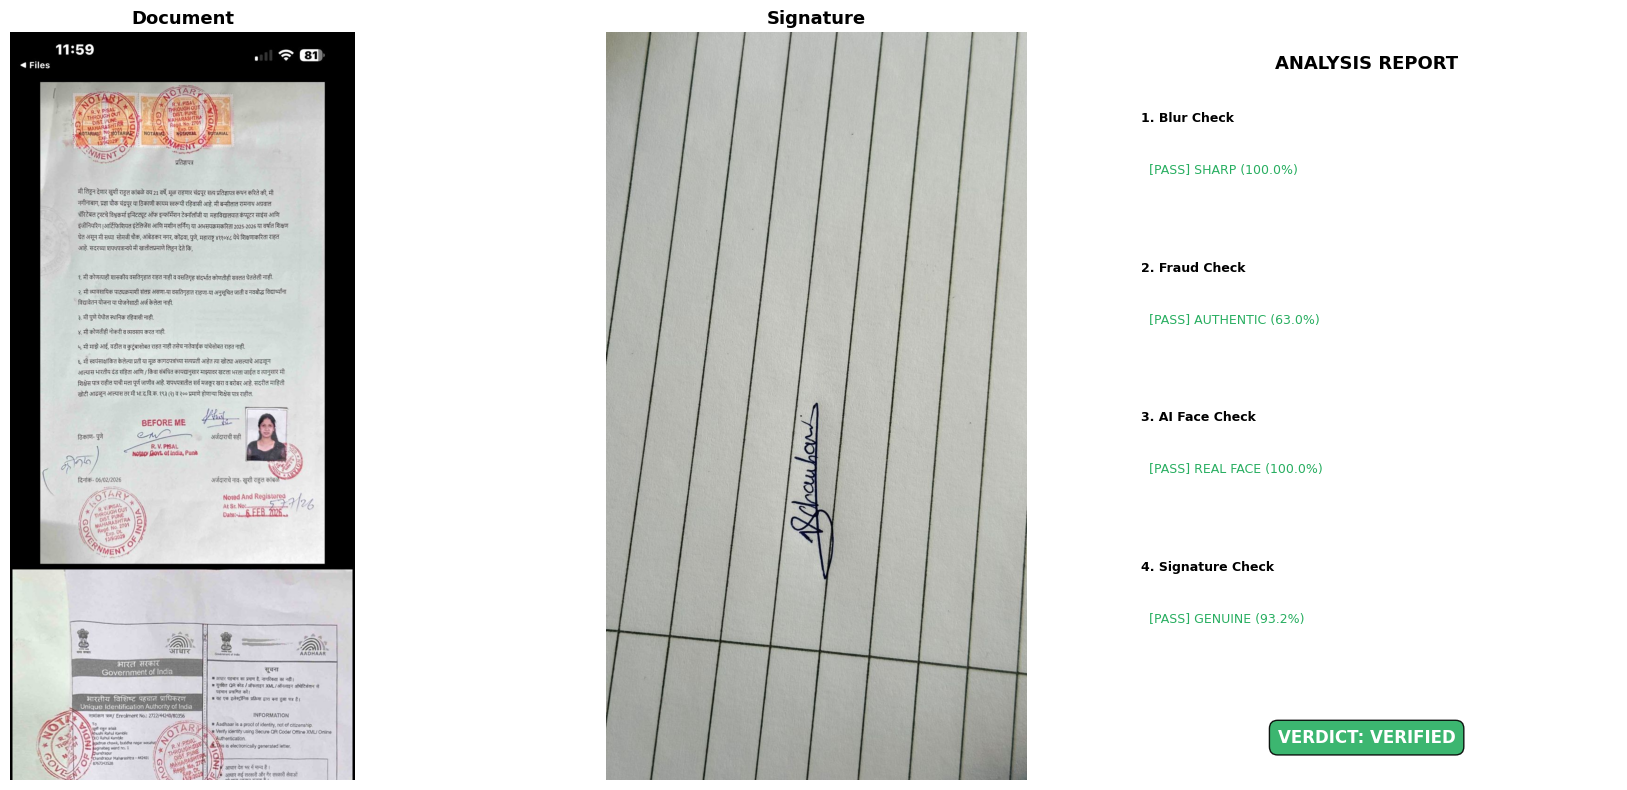

Report saved!


{'blur': {'status': 'PASS', 'label': 'SHARP', 'conf': 100.0},
 'ai_doc': {'status': 'SKIP', 'label': 'NEEDS RETRAINING', 'conf': 0},
 'fraud': {'status': 'PASS', 'label': 'AUTHENTIC', 'conf': 63.01441192626953},
 'ai_face': {'status': 'PASS', 'label': 'REAL FACE', 'conf': 100.0},
 'signature': {'status': 'PASS',
  'label': 'GENUINE',
  'conf': 93.18225979804993}}

In [46]:
analyze_document_v2(
    doc_path = "C:/Users/Vaibhav/Downloads/test222.jpeg",
    sig_path = "C:/Users/Vaibhav/Downloads/WhatsApp Image 2026-03-31 at 3.15.10 PM.jpeg"
)